## Libraries and Packages

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Videos and Background Subtraction

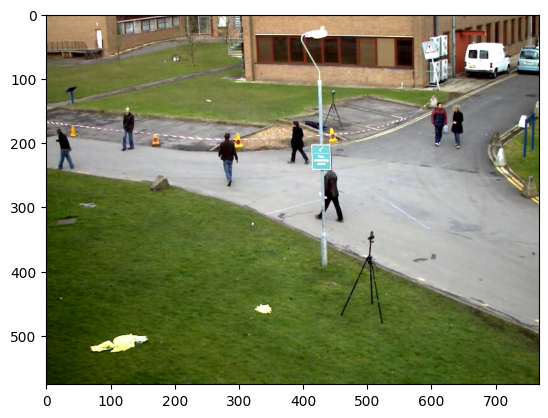

In [6]:
cap = cv2.VideoCapture('videos/vtest.avi')

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Exiting ...")
        break
    cv2.imshow('video', frame)
    if cv2.waitKey(1) & 0xFF == 27:
        plt.imshow(frame[...,::-1])
        break

cap.release()
cv2.destroyAllWindows()

In [8]:
#Lets define pre-processed Background Subtractor using MOG2
background_subtractor = cv2.createBackgroundSubtractorMOG2()

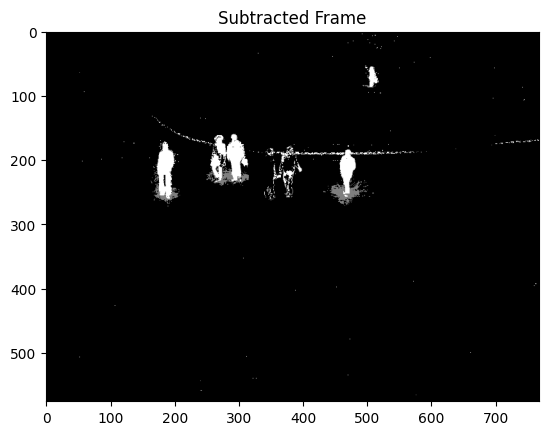

In [ ]:
cap = cv2.VideoCapture('videos/vtest.avi')

while True:
    ret, frame = cap.read()
    if frame is None:
        break
    
    #Apply background subtraction process on each frame
    #background_subtractor object will save this frame and its background for future processing over next frames
    fgMask = background_subtractor.apply(frame)
    
    #here we will put current frame index on pictures corner
    cv2.rectangle(frame, (10, 2), (100,20), (255,255,255), -1)
    cv2.putText(frame, str(cap.get(cv2.CAP_PROP_POS_FRAMES)), (15, 15),
               cv2.FONT_HERSHEY_SIMPLEX, 0.5 , (0,0,0))
    
    #Demonstrate Subtracted Background's frame and original one
    cv2.imshow('Original Frame', frame)
    cv2.imshow('FG Mask', fgMask)
    
    keyboard = cv2.waitKey(30)
    if keyboard == 'q' or keyboard == 27:
        plt.imshow(fgMask[...,::-1], cmap="gray"); plt.title("Subtracted Frame")
        break
cv2.destroyAllWindows()

## Lets Refine Subtracted Background noises with morphology operations   

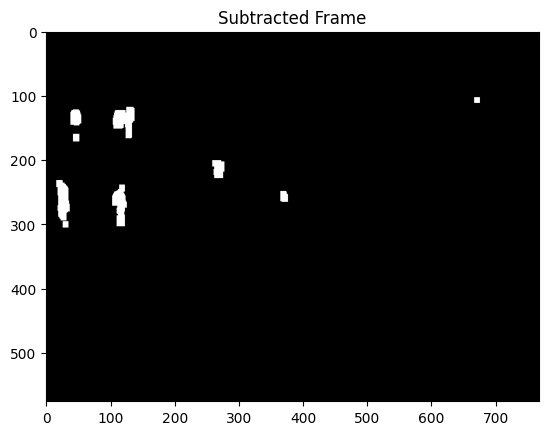

In [ ]:
capture = cv2.VideoCapture('videos/vtest.avi')

while True:
    ret, frame = capture.read()
    if frame is None:
        break
    
    fgMask = background_subtractor.apply(frame)
    
    kernel = np.ones((5,5), np.uint8)
    
    #Erosion and Dilation over frame aim to remove noises
    fgMask = cv2.erode(fgMask, kernel, iterations=2)
    fgMask = cv2.dilate(fgMask, kernel, iterations=2)
    fgMask[np.abs(fgMask) < 250] = 0
  
    
    cv2.rectangle(frame, (10, 2), (100,20), (255,255,255), -1)
    cv2.putText(frame, str(capture.get(cv2.CAP_PROP_POS_FRAMES)), (15, 15),
               cv2.FONT_HERSHEY_SIMPLEX, 0.5 , (0,0,0))
    
    #Demonstrate Subtracted Background's frame and original one
    cv2.imshow('Original Frame', frame)
    cv2.imshow('FG Mask', fgMask)
    
    keyboard = cv2.waitKey(30)
    if keyboard == 'q' or keyboard == 27:
        plt.imshow(fgMask[...,::-1], cmap="gray"); plt.title("Subtracted Frame")
        break

cv2.destroyAllWindows()

## Webcam project
in bank, governmental, and organization authorization, we may have a section for uploading our face interaction and dialog. How can we insure that we are not observing an image or fake action? we can use video subtraction aim to find face interactions in different directions

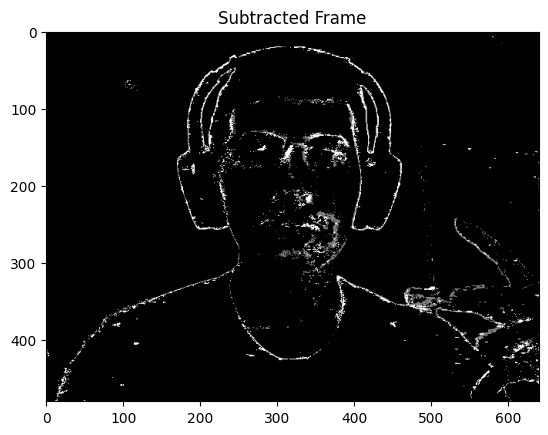

In [15]:
backSub = cv2.createBackgroundSubtractorMOG2()

capture = cv2.VideoCapture(0)

while True:
    ret, frame = capture.read()
    if frame is None:
        break
    
    fgMask = backSub.apply(frame)
    
    #Demonstrate Subtracted Background's frame and original one
    cv2.imshow('Original Frame', frame)
    cv2.imshow('FG Mask', fgMask)
    
    keyboard = cv2.waitKey(30)
    if keyboard == 'q' or keyboard == 27:
        plt.imshow(fgMask[...,::-1], cmap="gray"); plt.title("Subtracted Frame")
        break
cv2.destroyAllWindows()
capture.release()